# Molmo2 — Experimento Multi-Image Pointing

Compara el pointing del eje de simetría dando 1, 6, 14 y 26 vistas del mismo objeto en una sola llamada.

Solo se usa `ROT_000` por viewpoint (sin las 4 rotaciones).

### Dependencias
```bash
pip install transformers==4.57.1 torch pillow einops torchvision accelerate
```

## 0. Configuración

In [2]:
from pathlib import Path

# ── Ajusta estos parámetros ───────────────────────────────────────────────────
RENDERS_ROOT  = Path("../../data/renders")
SYMMETRY_TYPE = "axis_sym"
OBJECT_ID     = "1a9c1cbf1ca9ca24274623f5a5d0bcdc"
IMAGE_SIZE    = 224
ILLUMINATION  = "flat"

# Grupos a experimentar: primeras N vistas, solo ROT_000
EXPERIMENTS = [1, 6, 14, 26]

MODEL_ID   = "allenai/Molmo2-8B"
OUTPUT_DIR = Path("outputs") / OBJECT_ID / "multiview_experiment"
# ─────────────────────────────────────────────────────────────────────────────

render_dir = RENDERS_ROOT / SYMMETRY_TYPE / OBJECT_ID / str(IMAGE_SIZE) / ILLUMINATION
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Render dir : {render_dir}")
print(f"Existe     : {render_dir.exists()}")
print(f"Output dir : {OUTPUT_DIR}")
print(f"Experimentos: {EXPERIMENTS} vistas")

Render dir : ../../data/renders/axis_sym/1a9c1cbf1ca9ca24274623f5a5d0bcdc/224/flat
Existe     : True
Output dir : outputs/1a9c1cbf1ca9ca24274623f5a5d0bcdc/multiview_experiment
Experimentos: [1, 6, 14, 26] vistas


## 1. Cargar modelo

In [3]:
import torch
from transformers import AutoProcessor, AutoModelForImageTextToText

processor = AutoProcessor.from_pretrained(
    MODEL_ID,
    trust_remote_code=True,
    device_map="auto",
)
model = AutoModelForImageTextToText.from_pretrained(
    MODEL_ID,
    trust_remote_code=True,
    device_map="auto",
    torch_dtype=torch.bfloat16,
)
model.eval()
print(f"Modelo listo en: {model.device}")

/home/pespinoz/miniconda3/envs/tesis_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
`torch_dtype` is deprecated! Use `dtype` instead!
Loading checkpoint shards: 100%|██████████| 8/8 [00:17<00:00,  2.15s/it]


Modelo listo en: cuda:0


## 2. Utilidades

In [4]:
import re
import json
import math
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

PROMPT = "Point to where the main axis of symmetry intersects the edges of the shape."


def load_metadata(render_dir: Path) -> list[dict]:
    with open(render_dir / "metadata_all.json", encoding="utf-8") as f:
        return json.load(f)


def get_rot000_entries(metadata: list[dict], n_views: int) -> list[dict]:
    """
    Retorna las primeras n_views entradas con rotation_deg == 0.
    Una entrada por viewpoint (IND_00 … IND_{n_views-1}), sin rotaciones.
    """
    entries = [
        m for m in metadata
        if m["index"] < n_views and m["rotation_deg"] == 0
    ]
    # Ordenar por índice para garantizar IND_00, IND_01, ...
    return sorted(entries, key=lambda e: e["index"])


def load_images(entries: list[dict], render_dir: Path) -> list[Image.Image]:
    return [Image.open(render_dir / e["filename"]).convert("RGB") for e in entries]


# ── Parseo de coordenadas ─────────────────────────────────────────────────────
#
# Formato Molmo2 multi-imagen (paper §coordenadas, p.27):
#   <points coords="img_idx obj_id X Y img_idx obj_id X Y ; img_idx obj_id X Y ...">
#
# El ';' separa grupos de puntos por imagen.
# img_idx: 1-based, identifica la imagen del set.
# obj_id:  1-based, identifica el objeto dentro de la imagen.
# X, Y:    coordenadas en escala 0–1000, origen superior-izquierda.
#
# Formato imagen individual:
#   <points coords="RADIO ID X Y ID X Y ...">
#   El primer número es el radio (descartado), luego tripletas (ID, X, Y).

def parse_multiimage_coords(text: str, n_images: int) -> dict[int, list[tuple]]:
    """
    Parsea coordenadas del output multi-imagen de Molmo2.

    Retorna:
        dict {img_idx (0-based): [(obj_id, x, y), ...]}
        img_idx 0-based para indexar directamente la lista de imágenes.
    """
    match = re.search(r'coords="([^"]+)"', text)
    if not match:
        return {}

    raw = match.group(1)

    # Separar por ';' → grupos por imagen
    groups = [g.strip() for g in raw.split(";") if g.strip()]

    points_by_image: dict[int, list[tuple]] = {}

    for group in groups:
        nums = group.split()
        # Cada grupo: img_idx obj_id X Y  [obj_id X Y  ...]
        # El primer token es img_idx (1-based)
        if len(nums) < 4:
            continue
        try:
            img_idx = int(float(nums[0])) - 1  # convertir a 0-based
        except ValueError:
            continue

        if img_idx < 0 or img_idx >= n_images:
            continue

        # Tripletas (obj_id, X, Y) a partir del token 1
        pts = []
        rest = nums[1:]
        for i in range(0, len(rest) - 2, 3):
            try:
                obj_id = int(float(rest[i]))
                x      = float(rest[i + 1])
                y      = float(rest[i + 2])
                pts.append((obj_id, x, y))
            except ValueError:
                continue

        if pts:
            points_by_image.setdefault(img_idx, []).extend(pts)

    return points_by_image


def parse_single_image_coords(text: str) -> list[tuple]:
    """
    Parsea coordenadas del output imagen-individual de Molmo2.
    Formato: <points coords="RADIO  ID X Y  ID X Y ...">
    Retorna: [(obj_id, x, y), ...]
    """
    match = re.search(r'coords="([^"]+)"', text)
    if not match:
        return []
    raw = [float(n) for n in match.group(1).split()]
    if len(raw) < 4:
        return []
    raw = raw[1:]  # descartar radio
    pts = []
    for i in range(0, len(raw) - 2, 3):
        pts.append((int(raw[i]), raw[i + 1], raw[i + 2]))
    return pts


# ── Inferencia ────────────────────────────────────────────────────────────────

def run_inference(images: list[Image.Image], prompt: str = PROMPT) -> str:
    """
    Llama a Molmo2 con 1 o N imágenes y retorna el raw output.
    El content siempre es: [texto, img_1, img_2, ..., img_N]
    """
    content = [{"type": "text", "text": prompt}]
    for img in images:
        content.append({"type": "image", "image": img})

    messages = [{"role": "user", "content": content}]

    inputs = processor.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_tensors="pt",
        return_dict=True,
    )
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    max_tokens = 200 + len(images) * 50  # más tokens para más imágenes

    with torch.inference_mode():
        output_ids = model.generate(**inputs, max_new_tokens=max_tokens)

    return processor.tokenizer.decode(
        output_ids[0, inputs["input_ids"].size(1):],
        skip_special_tokens=True,
    )


# ── Visualización ─────────────────────────────────────────────────────────────

COLORS = ["red", "lime", "cyan", "yellow", "magenta", "orange",
          "white", "deepskyblue", "hotpink", "springgreen"]


def plot_group_results(
    images: list[Image.Image],
    entries: list[dict],
    points_by_image: dict[int, list[tuple]],
    n_views: int,
    raw_output: str,
    save_path: Path | None = None,
) -> None:
    """
    Grilla con todas las imágenes del grupo y sus puntos superpuestos.
    Debajo muestra el raw output del modelo.
    """
    n      = len(images)
    cols   = min(n, 6)
    rows   = math.ceil(n / cols)
    n_pts  = sum(len(v) for v in points_by_image.values())
    imgs_with_pts = len(points_by_image)

    fig = plt.figure(figsize=(cols * 3, rows * 3 + 1.2))
    fig.suptitle(
        f"{n_views} vista(s) | {n_pts} punto(s) en {imgs_with_pts}/{n} imágenes",
        fontsize=11, y=1.01,
    )

    for i, (img, entry) in enumerate(zip(images, entries)):
        ax = fig.add_subplot(rows, cols, i + 1)
        w, h = img.size
        ax.imshow(img)

        for obj_id, x, y in points_by_image.get(i, []):
            px = x / 1000 * w
            py = y / 1000 * h          # sin invertir Y
            c  = COLORS[(obj_id - 1) % len(COLORS)]
            ax.scatter(px, py, s=100, c=c, edgecolors="black",
                       linewidths=1, zorder=10)
            ax.text(px + 3, py + 3, str(obj_id),
                    color="white", fontsize=7, fontweight="bold",
                    zorder=11)

        az  = entry["azimuth"]
        el  = entry["elevation"]
        ax.set_title(f"IND {entry['index']:02d} | AZ{az} EL{el:+d}",
                     fontsize=7)
        ax.axis("off")

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=100)
        print(f"  → Guardado: {save_path}")

    plt.show()
    plt.close(fig)

    # Raw output debajo
    print(f"\n  Raw output:\n  {raw_output}\n")


print("Utilidades listas.")

Utilidades listas.


## 3. Experimentos: 1 → 6 → 14 → 26 vistas

Total imágenes en metadata: 456

════════════════════════════════════════════════════════════
  EXPERIMENTO: 1 vista(s)
════════════════════════════════════════════════════════════
  Imágenes cargadas: ['IND_00_AZ_090_EL_+89_ROT_000.png']
  Ejecutando inferencia...
  Puntos detectados: 6
  → Guardado: outputs/1a9c1cbf1ca9ca24274623f5a5d0bcdc/multiview_experiment/exp_01_views.png


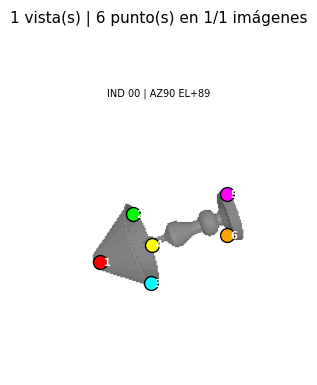


  Raw output:
  <points coords="1 1 282 581 2 402 402 3 470 657 4 471 515 5 749 329 6 751 480">main axis of symmetry intersections</points>


════════════════════════════════════════════════════════════
  EXPERIMENTO: 6 vista(s)
════════════════════════════════════════════════════════════
  Imágenes cargadas: ['IND_00_AZ_090_EL_+89_ROT_000.png', 'IND_01_AZ_137_EL_+79_ROT_000.png', 'IND_02_AZ_276_EL_+74_ROT_000.png', 'IND_03_AZ_052_EL_+71_ROT_000.png', 'IND_04_AZ_190_EL_+68_ROT_000.png', 'IND_05_AZ_328_EL_+65_ROT_000.png']
  Ejecutando inferencia...
  Puntos detectados: 6
  → Guardado: outputs/1a9c1cbf1ca9ca24274623f5a5d0bcdc/multiview_experiment/exp_06_views.png


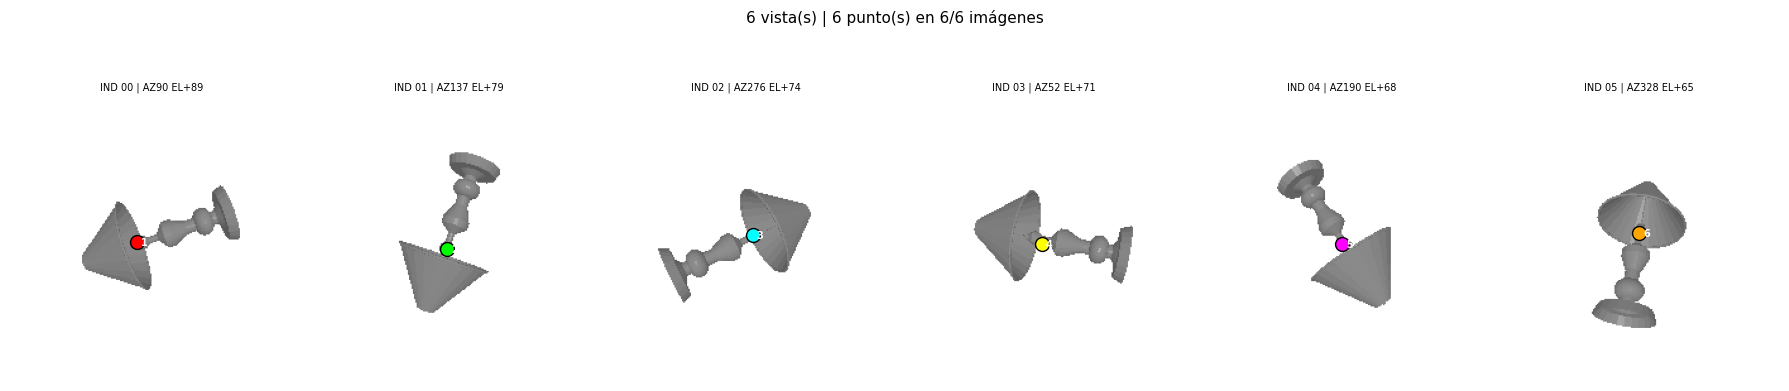


  Raw output:
  <points coords="1 1 449 505;2 2 492 529;3 3 520 481;4 4 492 512;5 5 502 512;6 6 499 473">where the main axis of symmetry intersects the edges of the shape</points>


════════════════════════════════════════════════════════════
  EXPERIMENTO: 14 vista(s)
════════════════════════════════════════════════════════════
  Imágenes cargadas: ['IND_00_AZ_090_EL_+89_ROT_000.png', 'IND_01_AZ_137_EL_+79_ROT_000.png', 'IND_02_AZ_276_EL_+74_ROT_000.png', 'IND_03_AZ_052_EL_+71_ROT_000.png', 'IND_04_AZ_190_EL_+68_ROT_000.png', 'IND_05_AZ_328_EL_+65_ROT_000.png', 'IND_06_AZ_105_EL_+63_ROT_000.png', 'IND_07_AZ_243_EL_+61_ROT_000.png', 'IND_08_AZ_020_EL_+59_ROT_000.png', 'IND_09_AZ_157_EL_+57_ROT_000.png', 'IND_10_AZ_296_EL_+55_ROT_000.png', 'IND_11_AZ_072_EL_+53_ROT_000.png', 'IND_12_AZ_211_EL_+51_ROT_000.png', 'IND_13_AZ_348_EL_+50_ROT_000.png']
  Ejecutando inferencia...
  Puntos detectados: 14
  → Guardado: outputs/1a9c1cbf1ca9ca24274623f5a5d0bcdc/multiview_experiment/exp_14_views.pn

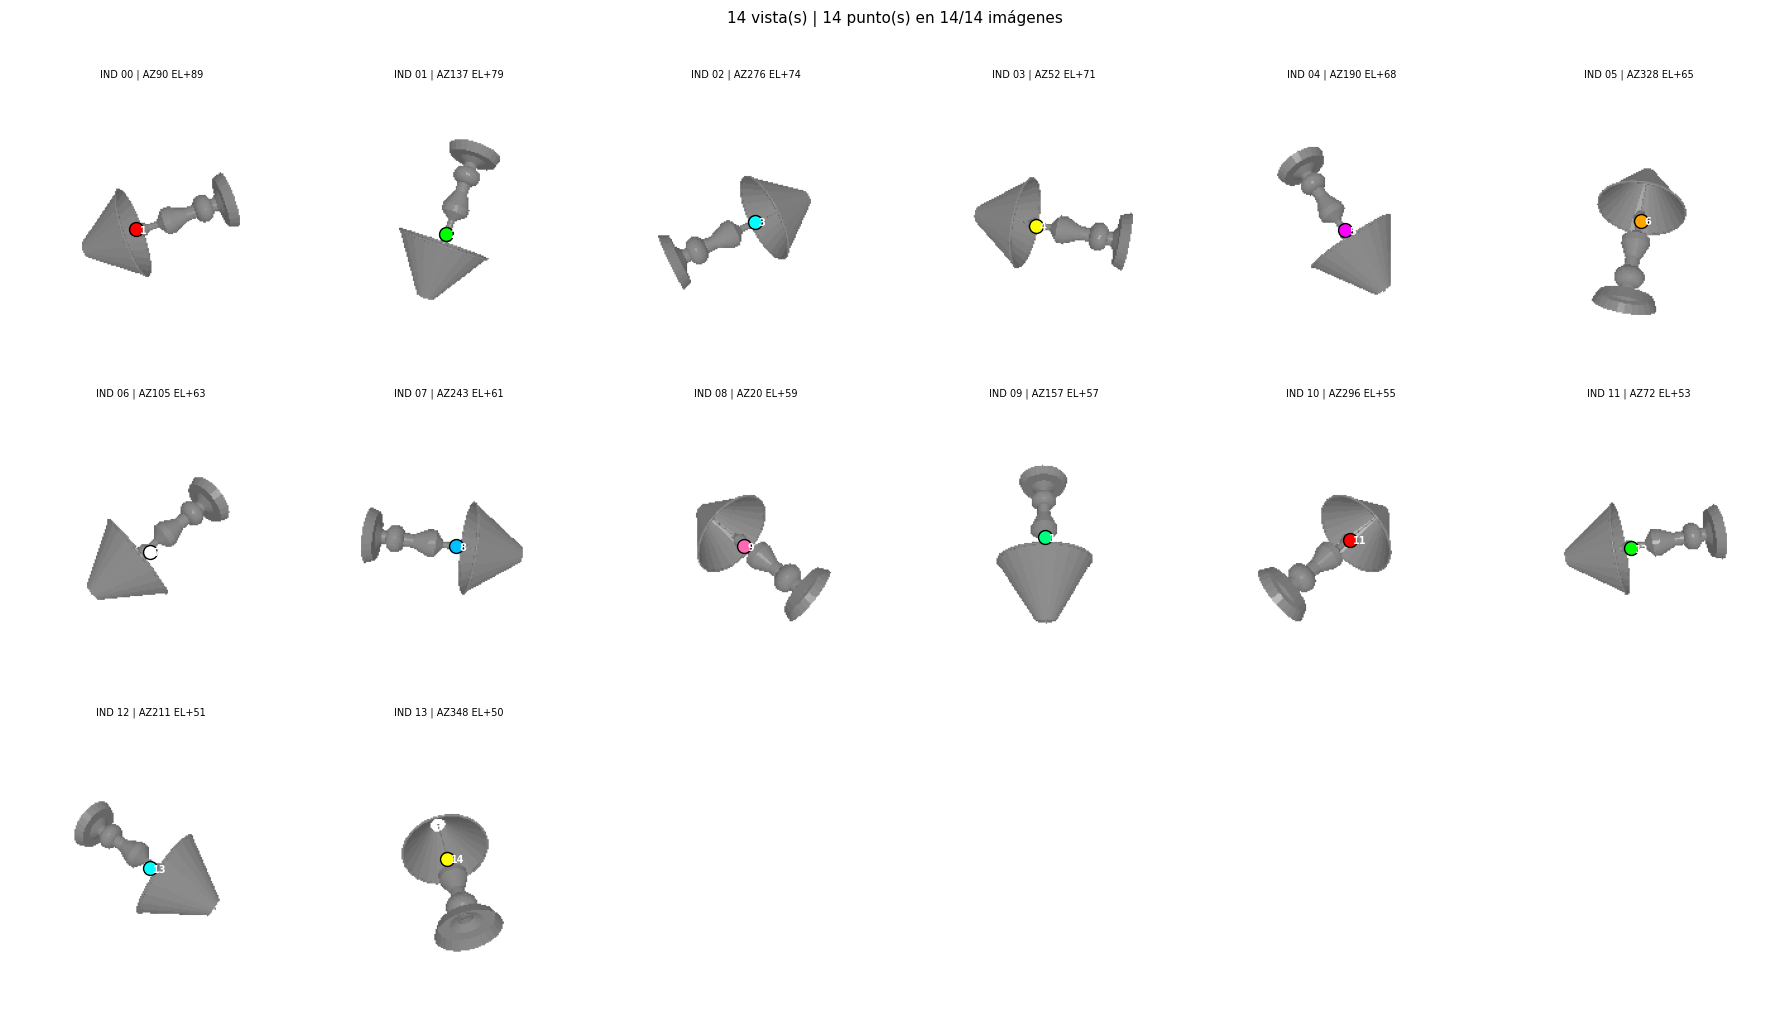


  Raw output:
  <points coords="1 1 443 507;2 2 489 523;3 3 527 481;4 4 471 494;5 5 512 511;6 6 504 477;7 7 492 519;8 8 523 499;9 9 489 499;10 10 501 468;11 11 527 477;12 12 471 507;13 13 492 511;14 14 492 477">where the main axis of symmetry intersects the edges of the shape</points>


════════════════════════════════════════════════════════════
  EXPERIMENTO: 26 vista(s)
════════════════════════════════════════════════════════════
  Imágenes cargadas: ['IND_00_AZ_090_EL_+89_ROT_000.png', 'IND_01_AZ_137_EL_+79_ROT_000.png', 'IND_02_AZ_276_EL_+74_ROT_000.png', 'IND_03_AZ_052_EL_+71_ROT_000.png', 'IND_04_AZ_190_EL_+68_ROT_000.png', 'IND_05_AZ_328_EL_+65_ROT_000.png', 'IND_06_AZ_105_EL_+63_ROT_000.png', 'IND_07_AZ_243_EL_+61_ROT_000.png', 'IND_08_AZ_020_EL_+59_ROT_000.png', 'IND_09_AZ_157_EL_+57_ROT_000.png', 'IND_10_AZ_296_EL_+55_ROT_000.png', 'IND_11_AZ_072_EL_+53_ROT_000.png', 'IND_12_AZ_211_EL_+51_ROT_000.png', 'IND_13_AZ_348_EL_+50_ROT_000.png', 'IND_14_AZ_125_EL_+48_ROT_000.png', 

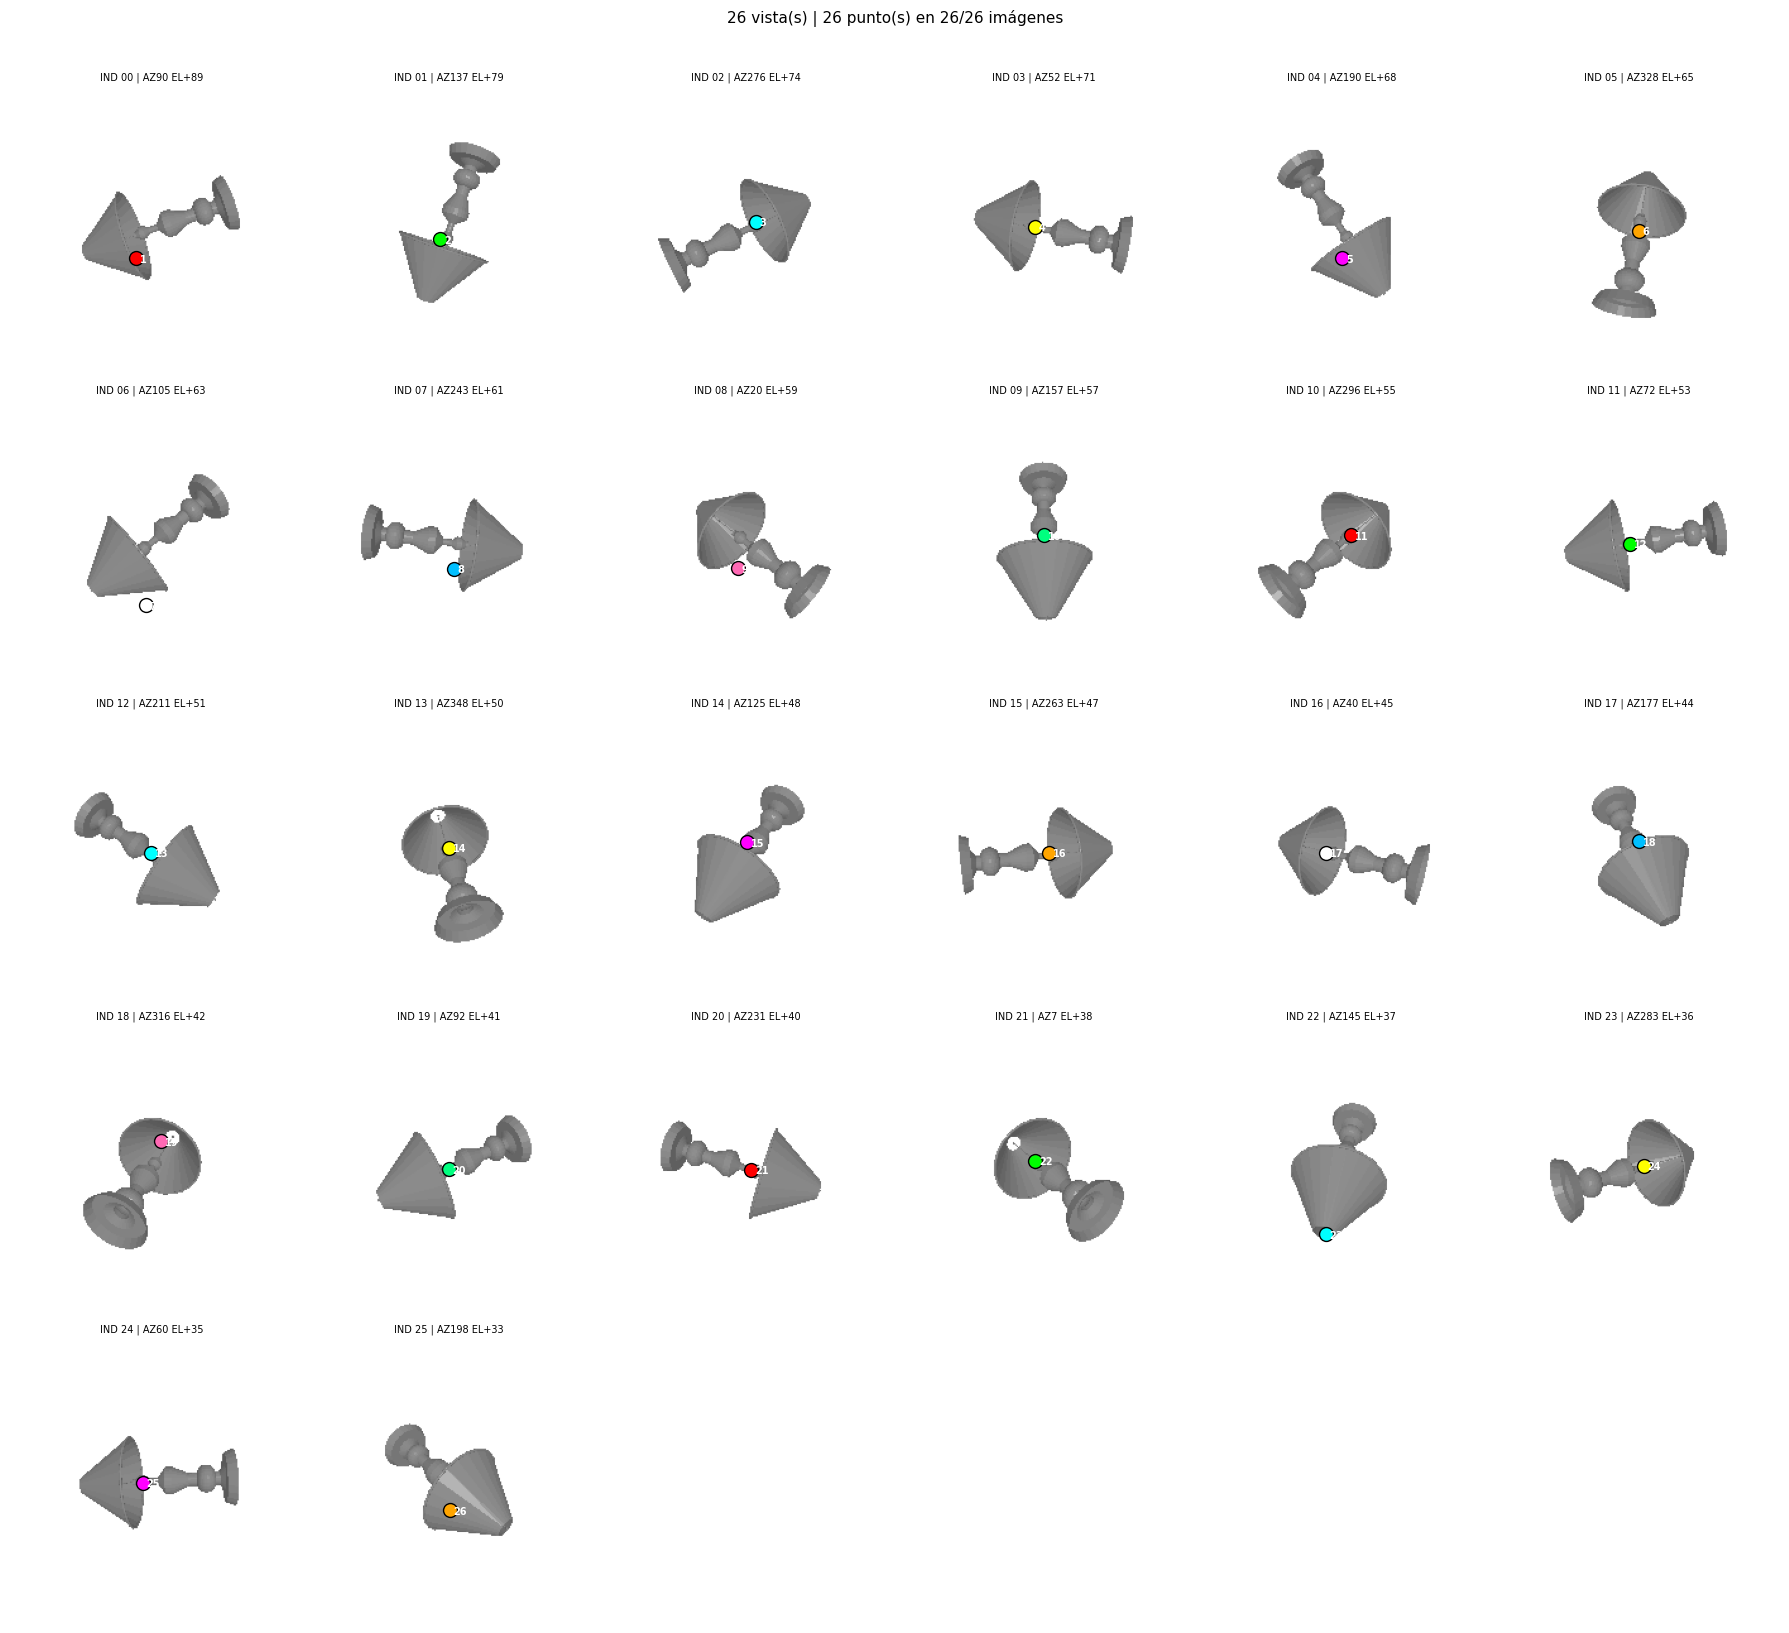


  Raw output:
  <points coords="1 1 443 599;2 2 468 531;3 3 532 469;4 4 468 488;5 5 502 599;6 6 498 501;7 7 479 719;8 8 516 590;9 9 468 588;10 10 498 472;11 11 532 472;12 12 468 501;13 13 498 488;14 14 498 469;15 15 502 451;16 16 516 488;17 17 443 488;18 18 498 447;19 19 532 401;20 20 498 499;21 21 516 501;22 22 468 469;23 23 443 729;24 24 516 488;25 25 468 501;26 26 502 599">where the main axis of symmetry intersects the edges of the shape</points>



In [5]:
metadata = load_metadata(render_dir)
print(f"Total imágenes en metadata: {len(metadata)}")

all_results = {}  # guarda resultados por grupo

for n_views in EXPERIMENTS:
    print("\n" + "═" * 60)
    print(f"  EXPERIMENTO: {n_views} vista(s)")
    print("═" * 60)

    entries = get_rot000_entries(metadata, n_views)
    images  = load_images(entries, render_dir)

    print(f"  Imágenes cargadas: {[e['filename'] for e in entries]}")
    print("  Ejecutando inferencia...")

    raw = run_inference(images)

    # Parsear según número de imágenes
    if n_views == 1:
        # Imagen individual: formato RADIO ID X Y ...
        pts_single = parse_single_image_coords(raw)
        points_by_image = {0: pts_single} if pts_single else {}
    else:
        # Multi-imagen: formato img_idx obj_id X Y ; ...
        points_by_image = parse_multiimage_coords(raw, n_images=n_views)

    n_pts = sum(len(v) for v in points_by_image.values())
    print(f"  Puntos detectados: {n_pts}")

    # Guardar resultado
    all_results[n_views] = {
        "raw_output":      raw,
        "points_by_image": {
            str(k): [{"obj_id": p[0], "x": p[1], "y": p[2]} for p in v]
            for k, v in points_by_image.items()
        },
        "entries": [
            {"filename": e["filename"], "index": e["index"],
             "azimuth": e["azimuth"], "elevation": e["elevation"]}
            for e in entries
        ],
        "n_points": n_pts,
        "n_images_with_points": len(points_by_image),
    }

    plot_group_results(
        images         = images,
        entries        = entries,
        points_by_image= points_by_image,
        n_views        = n_views,
        raw_output     = raw,
        save_path      = OUTPUT_DIR / f"exp_{n_views:02d}_views.png",
    )

## 4. Resumen comparativo

In [6]:
print(f"{'Vistas':<10} {'Imgs con puntos':<20} {'Total puntos':<15} {'¿Coords o texto?'}")
print("-" * 60)

for n_views, res in all_results.items():
    has_coords = "coords=" in res["raw_output"]
    fmt        = "coords" if has_coords else "texto descriptivo"
    print(
        f"{n_views:<10} "
        f"{res['n_images_with_points']}/{n_views:<17} "
        f"{res['n_points']:<15} "
        f"{fmt}"
    )

Vistas     Imgs con puntos      Total puntos    ¿Coords o texto?
------------------------------------------------------------
1          1/1                 6               coords
6          6/6                 6               coords
14         14/14                14              coords
26         26/26                26              coords


## 5. Guardar resultados

In [7]:
out_json = OUTPUT_DIR / "multiview_experiment_results.json"

# Serializar (entries ya son dicts, points_by_image tiene keys str)
with open(out_json, "w", encoding="utf-8") as f:
    json.dump(
        {
            "object_id":     OBJECT_ID,
            "symmetry_type": SYMMETRY_TYPE,
            "image_size":    IMAGE_SIZE,
            "illumination":  ILLUMINATION,
            "prompt":        PROMPT,
            "experiments":   all_results,
        },
        f, indent=2,
    )

print(f"Resultados guardados en: {out_json}")

Resultados guardados en: outputs/1a9c1cbf1ca9ca24274623f5a5d0bcdc/multiview_experiment/multiview_experiment_results.json


---
## Notas sobre el formato de coordenadas

### Imagen individual
```
<points coords="RADIO  ID X Y  ID X Y ...">
```
El primer número es el radio (descartado). Luego tripletas `(ID, X, Y)`.

### Multi-imagen (paper §coordenadas, p.27)
```
<points coords="img_idx obj_id X Y  obj_id X Y ; img_idx obj_id X Y ...">
```
- `;` separa grupos por imagen
- `img_idx`: índice de imagen, **1-based**
- `obj_id`: ID del objeto dentro de la imagen, 1-based
- `X, Y`: coordenadas en escala **0–1000**, origen **superior-izquierda** (sin invertir Y en matplotlib)

### Conversión a píxeles
```python
px = x / 1000 * image_width
py = y / 1000 * image_height   # sin invertir Y
```